# LMMS of data using Pymer4

- Pymer4 is a Python package for running LMMS via lme4 "under the hood" of Python. 
- This notebook is built separate from the main data analysis as the dependencies (i.e., certain Python libraries) to run Pymer4 are not compatible with newer Python libraries used in the primary analysis (e.g., pingouin stats package). 

In [1]:
## Environment Setup
## Run first to ensure R location can be found for Pymer4 LMMs
import os
import subprocess

## Automatically detect R path
r_home = subprocess.run(['R', 'RHOME'], capture_output=True, text=True).stdout.strip()
os.environ['R_HOME'] = r_home
print(f"R_HOME set to: {r_home}")

from pymer4.models import Lmer
import rpy2.robjects as ro
print(ro.r('R.version.string'))
print("pymer4 ready")

R_HOME set to: /opt/anaconda3/envs/lmm_env3/lib/R
[1] "R version 4.3.3 (2024-02-29)"

pymer4 ready


In [2]:
import pandas as pd
import numpy as np

In [3]:
# data_df = pd.read_excel('/Users/thomasgooding/Desktop/Rutgers_SQLdata/physio_demo_data_cleaned_04302026.xlsx') ## old data

data_df = pd.read_csv('/Users/thomasgooding/Desktop/Rutgers_SQLdata/Clean_scripts/SQL_data_052626.csv')

data_df.head()

,ID6,from_study,timepoint,RRIMin,RRImax,RRImean,RRIRmssd,RRIPnn50,RRIDev,RRICvs,...,RRISUlf_ln,RRISVlf_ln,RRISLf_ln,RRISHf_ln,RRISLfHF_ln,RRISnLf_ln,RRISnHf_ln,RRI_ln,RRIRmssd_ln,RRIPnn50_ln
0,220085,Athlete,B1,NaN,NaN,NaN,134.0,69.2,109.0,NaN,...,NaN,NaN,7.86,8.22,NaN,NaN,NaN,NaN,4.90,4.24
1,220085,Athlete,6P,NaN,NaN,NaN,153.0,57.5,189.0,NaN,...,NaN,NaN,9.84,8.17,NaN,NaN,NaN,NaN,5.03,4.05
2,220107,Athlete,B1,NaN,NaN,NaN,25.0,4.3,43.0,NaN,...,NaN,NaN,6.71,5.60,NaN,NaN,NaN,NaN,3.22,1.46
3,220107,Athlete,6P,NaN,NaN,NaN,68.0,26.8,125.0,NaN,...,NaN,NaN,9.37,6.61,NaN,NaN,NaN,NaN,4.22,3.29
4,220109,Athlete,B1,NaN,NaN,NaN,29.0,5.3,50.0,NaN,...,NaN,NaN,6.47,4.58,NaN,NaN,NaN,NaN,3.37,1.67


### Data Cleaning

In [4]:
data_df['race_text'] = data_df['race_text'].astype(str)
data_df['hispanic'] = data_df['hispanic'].astype(str)

In [5]:
# Explicitly set as ordered categorical with reference levels
data_df['timepoint'] = pd.Categorical(
    data_df['timepoint'], 
    categories=['B1', '6P'],  # B1 first = reference
    ordered=True
)
data_df['bmi_cat'] = pd.Categorical(
    data_df['bmi_cat'],
    categories=['Healthy weight', 'Underweight', 'Overweight', 
                'Obese'],
    ordered=True
)


### LMMs using Pymer4

- Runs lme4 (R) in Python to produce the same results for LMMs either in R or Python

#### HR Mean

In [6]:
print("Timepoint levels:", data_df['timepoint'].unique())
print("---")
print("BMI category levels:", data_df['bmi_cat'].unique())

Timepoint levels: ['B1', '6P']
Categories (2, object): ['B1' < '6P']
---
BMI category levels: [NaN, 'Overweight', 'Healthy weight', 'Underweight', 'Obese']
Categories (4, object): ['Healthy weight' < 'Underweight' < 'Overweight' < 'Obese']


In [7]:
## make new df to test/modify for running LMMS
## linear mixed-effects models (lmer) is correct choice for continuous DV and use of fixed effects + random effects
lmm_df = data_df.copy()

In [8]:
lmm_df['bmi_cat'].unique()

[NaN, 'Overweight', 'Healthy weight', 'Underweight', 'Obese']
Categories (4, object): ['Healthy weight' < 'Underweight' < 'Overweight' < 'Obese']

In [9]:
## make new df to test/modify for running LMMS
## filter out Nan alues for the LMM_df
lmm_df = data_df.copy()
lmm_df = data_df.dropna(subset=['bmi_cat']).copy()

model_HRMean = Lmer(
    'HRMean ~ timepoint * bmi_cat + (1|ID6)',
    data=lmm_df
)

model_HRMean.fit(
    factors={
        'timepoint': ['B1', '6P'],        # B1 first = B1 as reference
        'bmi_cat': ['Healthy weight',      # Healthy weight first = reference
                    'Underweight',
                    'Overweight',
                    'Obese'
]
    },
    summarize=True
)


Linear mixed model fit by REML [’lmerMod’]
Formula: HRMean~timepoint*bmi_cat+(1|ID6)

Family: gaussian	 Inference: parametric

Number of observations: 670	 Groups: {'ID6': 335.0}

Log-likelihood: -2361.972 	 AIC: 4743.944

Random effects:

                 Name      Var     Std
ID6       (Intercept)  100.578  10.029
Residual                22.034   4.694

No random effect correlations specified

Fixed effects:



,Estimate,2.5_ci,97.5_ci,SE,DF,T-stat,P-val,Sig
(Intercept),70.614,69.035,72.192,0.805,395.724,87.671,0.000,***
timepoint1,5.029,4.082,5.975,0.483,331.000,10.414,0.000,***
bmi_cat1,7.006,-0.036,14.048,3.593,395.724,1.950,0.052,.
bmi_cat2,-0.904,-3.615,1.806,1.383,395.724,-0.654,0.514,
bmi_cat3,0.830,-2.987,4.647,1.947,395.724,0.426,0.670,
timepoint1:bmi_cat1,-3.819,-8.040,0.403,2.154,331.000,-1.773,0.077,.
timepoint1:bmi_cat2,-0.459,-2.085,1.166,0.829,331.000,-0.554,0.580,
timepoint1:bmi_cat3,-2.616,-4.904,-0.327,1.168,331.000,-2.240,0.026,*


In [10]:
lmm_df['bmi_cat'].unique()

['Overweight', 'Healthy weight', 'Underweight', 'Obese']
Categories (4, object): ['Healthy weight' < 'Underweight' < 'Overweight' < 'Obese']

In [11]:
 ## random effect variances
print(model_HRMean.ranef_var)

                 Name         Var        Std
ID6       (Intercept)  100.577703  10.028844
Residual                22.034176   4.694058


In [12]:
## make new df to test/modify for running LMMS
## filter out Nan alues for the LMM_df
lmm_df = data_df.copy()
lmm_df = data_df.dropna(subset=['bmi_cat']).copy()

model_HRMean = Lmer(
    'HRMean ~ timepoint * bmi_cat + (1|ID6)',
    data=lmm_df
)

model_HRMean.fit(
    factors={
        'timepoint': ['6P', 'B1'],        # 6P first = 6P as reference
        'bmi_cat': ['Healthy weight',      # Healthy weight first = reference
                    'Underweight',
                    'Overweight',
                    'Obese']
    },
    summarize=True
)


Linear mixed model fit by REML [’lmerMod’]
Formula: HRMean~timepoint*bmi_cat+(1|ID6)

Family: gaussian	 Inference: parametric

Number of observations: 670	 Groups: {'ID6': 335.0}

Log-likelihood: -2361.972 	 AIC: 4743.944

Random effects:

                 Name      Var     Std
ID6       (Intercept)  100.578  10.029
Residual                22.034   4.694

No random effect correlations specified

Fixed effects:



,Estimate,2.5_ci,97.5_ci,SE,DF,T-stat,P-val,Sig
(Intercept),75.642,74.064,77.221,0.805,395.724,93.914,0.000,***
timepoint1,-5.029,-5.975,-4.082,0.483,331.000,-10.414,0.000,***
bmi_cat1,3.188,-3.855,10.230,3.593,395.724,0.887,0.376,
bmi_cat2,-1.364,-4.075,1.347,1.383,395.724,-0.986,0.325,
bmi_cat3,-1.786,-5.603,2.031,1.947,395.724,-0.917,0.360,
timepoint1:bmi_cat1,3.819,-0.403,8.040,2.154,331.000,1.773,0.077,.
timepoint1:bmi_cat2,0.459,-1.166,2.085,0.829,331.000,0.554,0.580,
timepoint1:bmi_cat3,2.616,0.327,4.904,1.168,331.000,2.240,0.026,*


In [ ]:
## Calculating Intraclass correlation coefficient
ranef_var = model_HRMean.ranef_var['Var'].iloc[0]
resid_var = model_HRMean.ranef_var['Var'].iloc[1]
icc = ranef_var / (ranef_var + resid_var)
print(f"ICC: {icc:.3f}")

ICC: 0.820


In [14]:
display(model_HRMean.anova())

SS Type III Analysis of Variance Table with Satterthwaite approximated degrees of freedom:
(NOTE: Using original model contrasts, orthogonality not guaranteed)


,SS,MS,NumDF,DenomDF,F-stat,P-val,Sig
timepoint,618.730710,618.730710,1,331.000010,28.080501,2.128958e-07,***
bmi_cat,74.136033,24.712011,3,330.999974,1.121531,3.403812e-01,
timepoint:bmi_cat,165.613747,55.204582,3,331.000010,2.505407,5.903215e-02,.


In [15]:
display(model_HRMean.coefs.round(3))

,Estimate,2.5_ci,97.5_ci,SE,DF,T-stat,P-val,Sig
(Intercept),75.642,74.064,77.221,0.805,395.724,93.914,0.000,***
timepoint1,-5.029,-5.975,-4.082,0.483,331.000,-10.414,0.000,***
bmi_cat1,3.188,-3.855,10.230,3.593,395.724,0.887,0.376,
bmi_cat2,-1.364,-4.075,1.347,1.383,395.724,-0.986,0.325,
bmi_cat3,-1.786,-5.603,2.031,1.947,395.724,-0.917,0.360,
timepoint1:bmi_cat1,3.819,-0.403,8.040,2.154,331.000,1.773,0.077,.
timepoint1:bmi_cat2,0.459,-1.166,2.085,0.829,331.000,0.554,0.580,
timepoint1:bmi_cat3,2.616,0.327,4.904,1.168,331.000,2.240,0.026,*


In [16]:
anova_table = model_HRMean.anova()

# Partial eta squared = SS_effect / (SS_effect + SS_residual)
# For each effect
for idx, row in anova_table.iterrows():
    ss_effect = row['SS']
    ss_resid = resid_var * row['DenomDF']
    partial_eta2 = ss_effect / (ss_effect + ss_resid)
    display(f"{idx}: partial η² = {partial_eta2:.3f}")

SS Type III Analysis of Variance Table with Satterthwaite approximated degrees of freedom:
(NOTE: Using original model contrasts, orthogonality not guaranteed)


'timepoint: partial η² = 0.078'

'bmi_cat: partial η² = 0.010'

'timepoint:bmi_cat: partial η² = 0.022'

<Axes: xlabel='HRMean', ylabel='Count'>

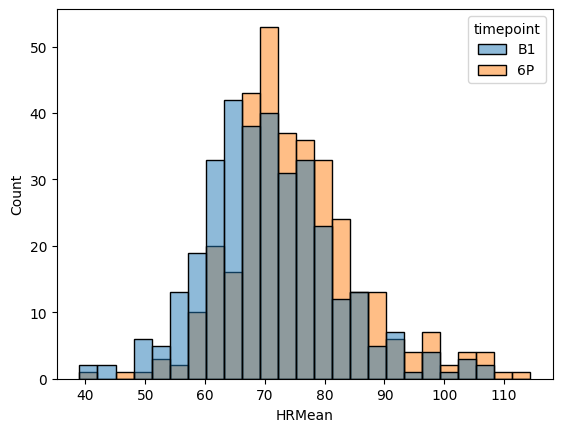

In [17]:
import seaborn as sns 

sns.histplot(data=lmm_df, x='HRMean', hue='timepoint')

In [18]:
# # Check group means to verify intercept matches B1 Healthy weight mean
# lmm_df.groupby(['timepoint', 'bmi_cat'])['HRMean'].mean().unstack()

In [19]:
posthoc = model_HRMean.post_hoc(marginal_vars='timepoint', grouping_vars='bmi_cat')

pd.set_option('display.max_columns', None)      # show all columns
pd.set_option('display.width', None)             # no line wrapping
pd.set_option('display.float_format', '{:.3f}'.format)  # round to 3 decimal places

## display the marginal means
display(posthoc[0].round(3))
## display the pairwise contrasts
display(posthoc[1].round(3))

,timepoint,bmi_cat,Estimate,2.5_ci,97.5_ci,SE,DF
1,6P,Healthy weight,75.642,74.059,77.226,0.805,395.724
2,B1,Healthy weight,70.614,69.030,72.197,0.805,395.724
3,6P,Underweight,78.830,71.946,85.714,3.502,395.724
4,B1,Underweight,77.620,70.736,84.504,3.502,395.724
5,6P,Overweight,74.278,72.068,76.489,1.124,395.724
6,B1,Overweight,69.709,67.499,71.920,1.124,395.724
7,6P,Obese,73.856,70.371,77.342,1.773,395.724
8,B1,Obese,71.444,67.958,74.929,1.773,395.724


,Contrast,bmi_cat,Estimate,2.5_ci,97.5_ci,SE,DF,T-stat,P-val,Sig
1,6P - B1,Healthy weight,5.029,4.079,5.978,0.483,331.000,10.414,0.000,***
2,6P - B1,Underweight,1.210,-2.920,5.340,2.099,331.000,0.576,0.565,
3,6P - B1,Overweight,4.569,3.243,5.895,0.674,331.000,6.779,0.000,***
4,6P - B1,Obese,2.413,0.322,4.504,1.063,331.000,2.270,0.024,*


In [20]:
from statsmodels.stats.multitest import multipletests

p_vals = posthoc[1]['P-val'].values
reject, p_corr, _, _ = multipletests(p_vals, method='bonferroni')
posthoc[1]['P-val-bonf'] = p_corr.round(4)
posthoc[1]['Reject_null'] = reject
display(posthoc[1][['Contrast', 'bmi_cat', 'Estimate', 'P-val', 'P-val-bonf', 'Reject_null']].round(3))

,Contrast,bmi_cat,Estimate,P-val,P-val-bonf,Reject_null
1,6P - B1,Healthy weight,5.029,0.000,0.000,True
2,6P - B1,Underweight,1.210,0.565,1.000,False
3,6P - B1,Overweight,4.569,0.000,0.000,True
4,6P - B1,Obese,2.413,0.024,0.096,False


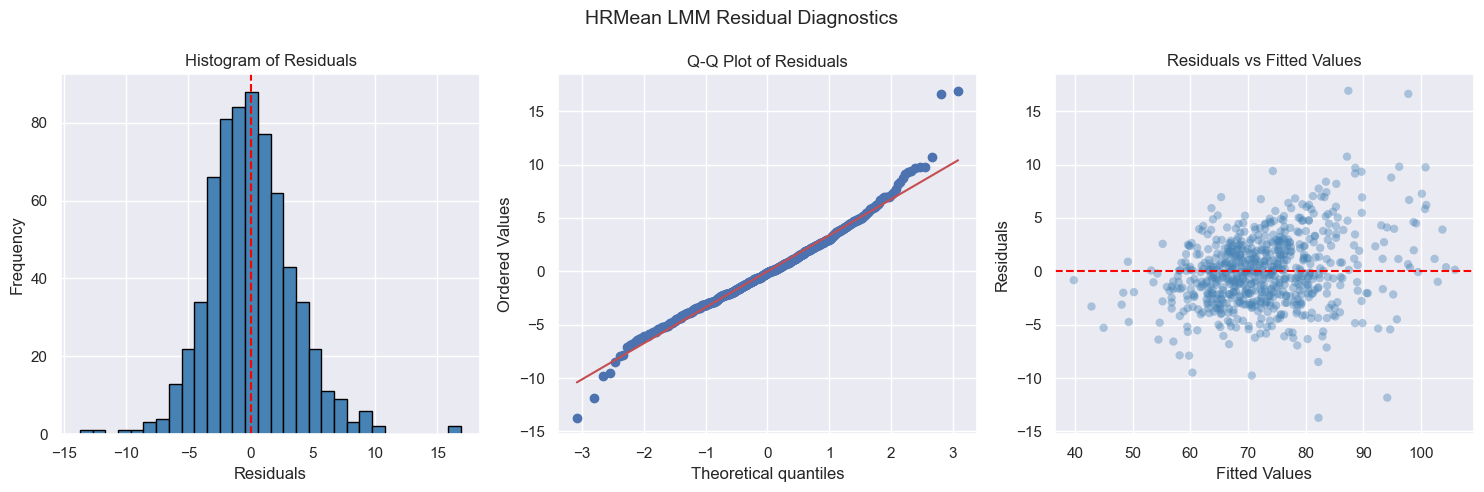

In [30]:
import matplotlib.pyplot as plt
import scipy.stats as stats
sns.set_theme(style='darkgrid')

## Extract residuals from the fitted model
residuals = model_HRMean.residuals

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('HRMean LMM Residual Diagnostics', fontsize=14)

## Plot 1: Histogram of residuals
axes[0].hist(residuals, bins=30, edgecolor='black', color='steelblue')
axes[0].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[0].set_title('Histogram of Residuals')
axes[0].set_xlabel('Residuals')
axes[0].set_ylabel('Frequency')

## Plot 2: Q-Q plot
stats.probplot(residuals, dist='norm', plot=axes[1])
axes[1].set_title('Q-Q Plot of Residuals')

## Plot 3: Residuals vs Fitted values
fitted = model_HRMean.fits
axes[2].scatter(fitted, residuals, alpha=0.4, color='steelblue', edgecolors='none')
axes[2].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[2].set_title('Residuals vs Fitted Values')
axes[2].set_xlabel('Fitted Values')
axes[2].set_ylabel('Residuals')

plt.tight_layout()
plt.show()

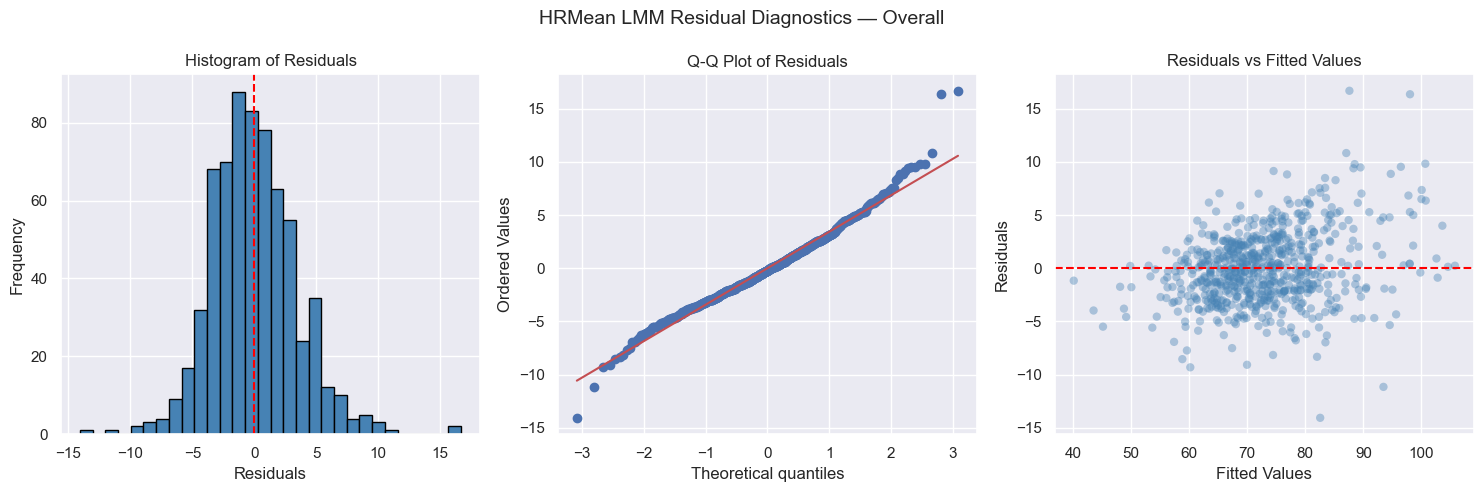

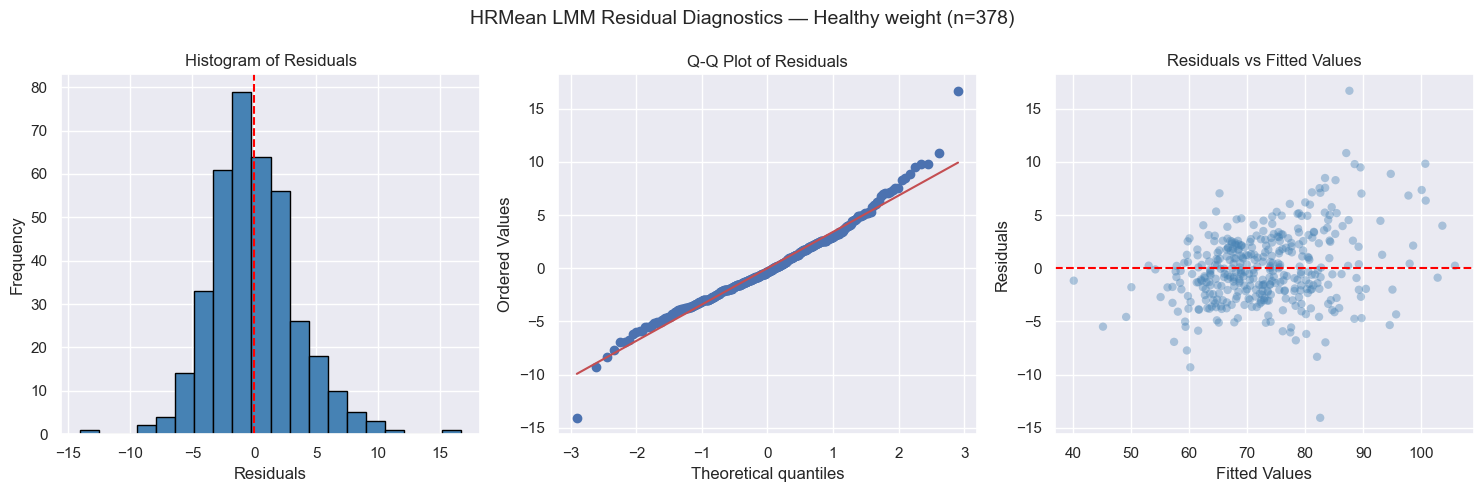

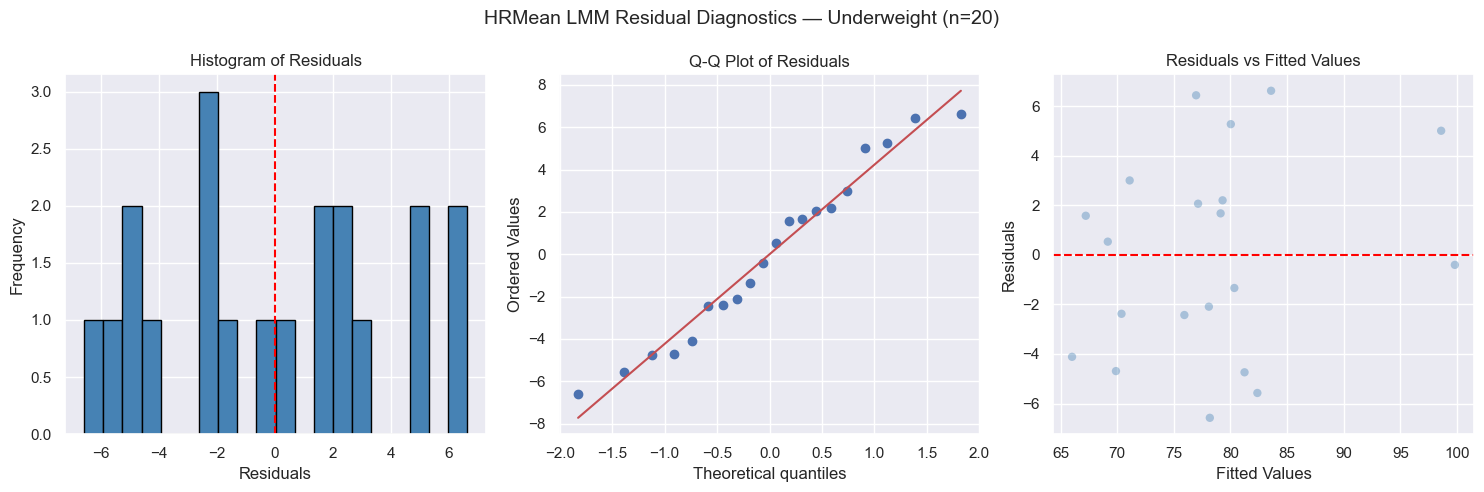

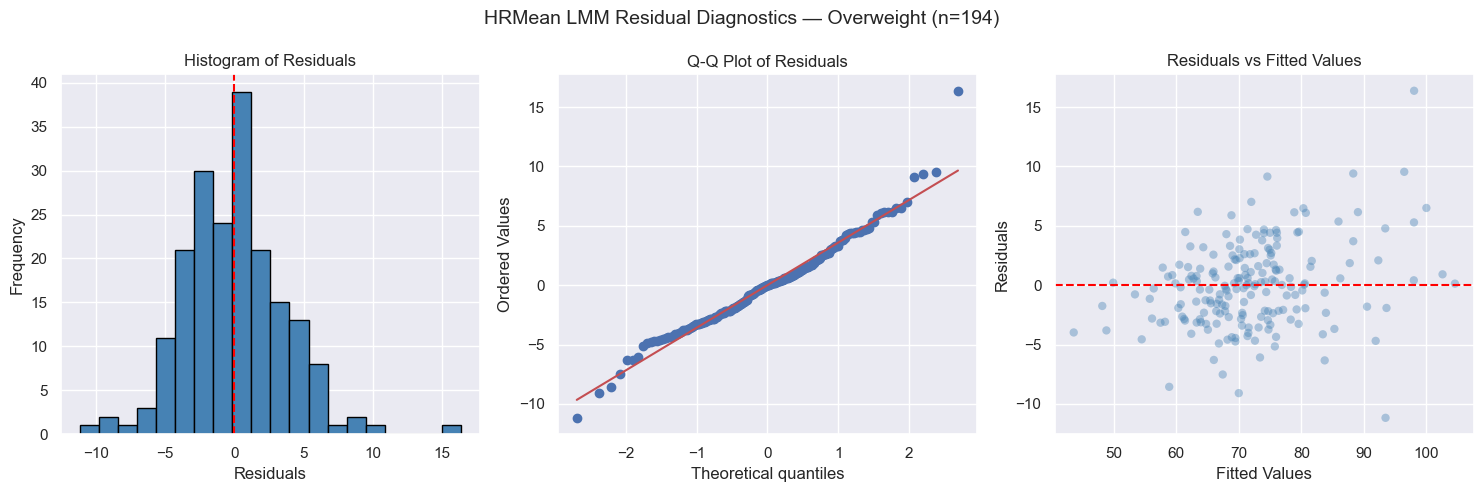

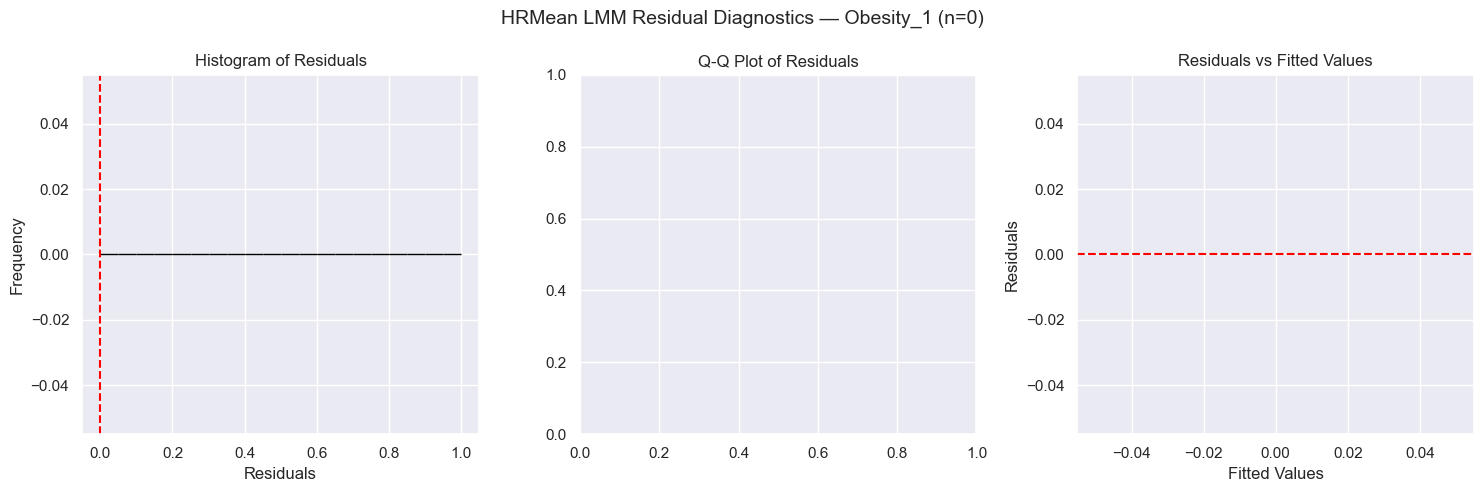

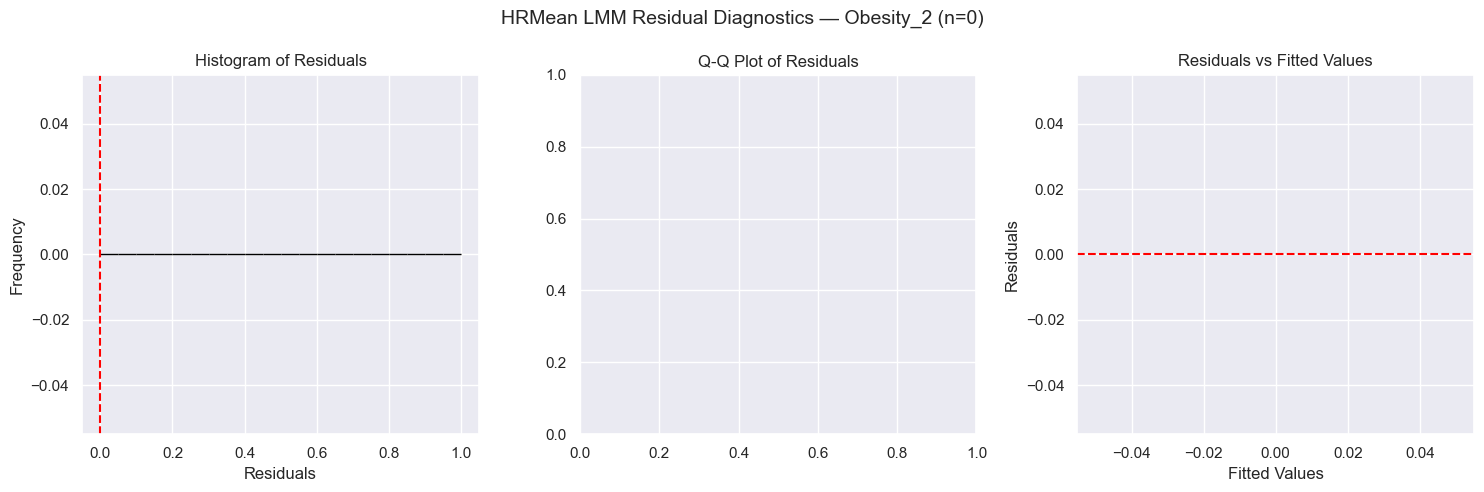

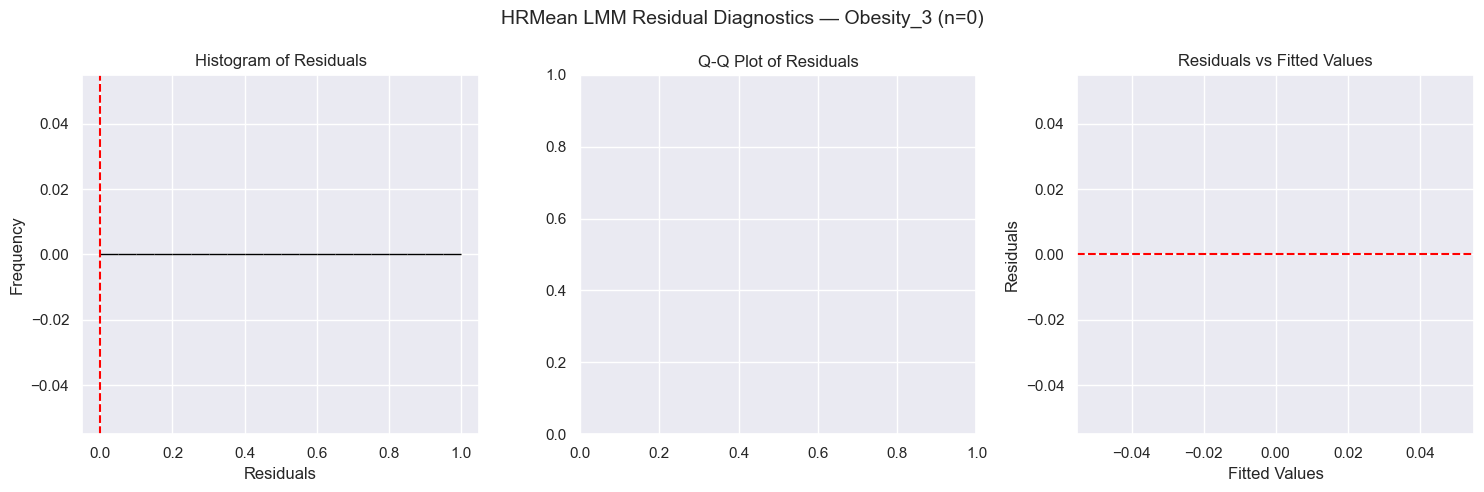

In [22]:
import matplotlib.pyplot as plt
import scipy.stats as stats
import seaborn as sns
sns.set_theme(style='darkgrid')

# Extract residuals and fitted values, attach bmi_cat from lmm_df
residuals = model_HRMean.residuals
fitted = model_HRMean.fits

resid_df = pd.DataFrame({
    'residuals': residuals,
    'fitted': fitted,
    'bmi_cat': lmm_df['bmi_cat'].values
})

# ── Overall Diagnostics ────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('HRMean LMM Residual Diagnostics — Overall', fontsize=14)

axes[0].hist(residuals, bins=30, edgecolor='black', color='steelblue')
axes[0].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[0].set_title('Histogram of Residuals')
axes[0].set_xlabel('Residuals')
axes[0].set_ylabel('Frequency')

stats.probplot(residuals, dist='norm', plot=axes[1])
axes[1].set_title('Q-Q Plot of Residuals')

axes[2].scatter(fitted, residuals, alpha=0.4, color='steelblue', edgecolors='none')
axes[2].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[2].set_title('Residuals vs Fitted Values')
axes[2].set_xlabel('Fitted Values')
axes[2].set_ylabel('Residuals')

plt.tight_layout()
plt.show()

# ── Per BMI Category Diagnostics ──────────────────────────────────
bmi_groups = ['Healthy weight', 'Underweight', 'Overweight',
              'Obesity_1', 'Obesity_2', 'Obesity_3']

for group in bmi_groups:
    group_data = resid_df[resid_df['bmi_cat'] == group]
    group_resid = group_data['residuals'].values
    group_fitted = group_data['fitted'].values
    n = len(group_resid)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(f'HRMean LMM Residual Diagnostics — {group} (n={n})', fontsize=14)

    # Histogram
    axes[0].hist(group_resid, bins=20, edgecolor='black', color='steelblue')
    axes[0].axvline(0, color='red', linestyle='--', linewidth=1.5)
    axes[0].set_title('Histogram of Residuals')
    axes[0].set_xlabel('Residuals')
    axes[0].set_ylabel('Frequency')

    # Q-Q plot
    stats.probplot(group_resid, dist='norm', plot=axes[1])
    axes[1].set_title('Q-Q Plot of Residuals')

    # Residuals vs Fitted
    axes[2].scatter(group_fitted, group_resid, alpha=0.4, 
                    color='steelblue', edgecolors='none')
    axes[2].axhline(0, color='red', linestyle='--', linewidth=1.5)
    axes[2].set_title('Residuals vs Fitted Values')
    axes[2].set_xlabel('Fitted Values')
    axes[2].set_ylabel('Residuals')

    plt.tight_layout()
    plt.show()

#### RRIRSLf_ln

In [24]:
## make new df to test/modify for running LMMS
## filter out Nan alues for the LMM_df
lmm_df = data_df.copy()
lmm_df = data_df.dropna(subset=['bmi_cat']).copy()

model_RRIRSLf_ln = Lmer(
    'HRMean ~ timepoint * bmi_cat * sex + (1|ID6)',
    data=lmm_df
)

model_RRIRSLf_ln.fit(
    factors={
        'timepoint': ['6P', 'B1'],        # 6P first = 6P as reference
        'bmi_cat': ['Healthy weight',      # Healthy weight first = reference
                    'Underweight',
                    'Overweight',
                    'Obese'],
        'sex': ['M', 'F']
    },
    summarize=True
)


Linear mixed model fit by REML [’lmerMod’]
Formula: HRMean~timepoint*bmi_cat*sex+(1|ID6)

Family: gaussian	 Inference: parametric

Number of observations: 670	 Groups: {'ID6': 335.0}

Log-likelihood: -2335.332 	 AIC: 4706.664

Random effects:

                 Name    Var   Std
ID6       (Intercept) 98.309 9.915
Residual              21.583 4.646

No random effect correlations specified

Fixed effects:



,Estimate,2.5_ci,97.5_ci,SE,DF,T-stat,P-val,Sig
(Intercept),72.858,70.064,75.652,1.426,391.062,51.110,0.000,***
timepoint1,-5.168,-6.844,-3.491,0.855,327.000,-6.042,0.000,***
bmi_cat1,1.242,-20.399,22.884,11.042,391.062,0.113,0.910,
bmi_cat2,-0.322,-4.494,3.849,2.128,391.062,-0.151,0.880,
bmi_cat3,4.522,-2.817,11.861,3.744,391.062,1.208,0.228,
sex1,4.049,0.680,7.417,1.719,391.062,2.355,0.019,*
timepoint1:bmi_cat1,-3.732,-16.718,9.254,6.626,327.000,-0.563,0.574,
timepoint1:bmi_cat2,-0.343,-2.846,2.160,1.277,327.000,-0.268,0.789,
timepoint1:bmi_cat3,-2.122,-6.526,2.281,2.247,327.000,-0.945,0.346,
timepoint1:sex1,0.202,-1.819,2.224,1.031,327.000,0.196,0.845,


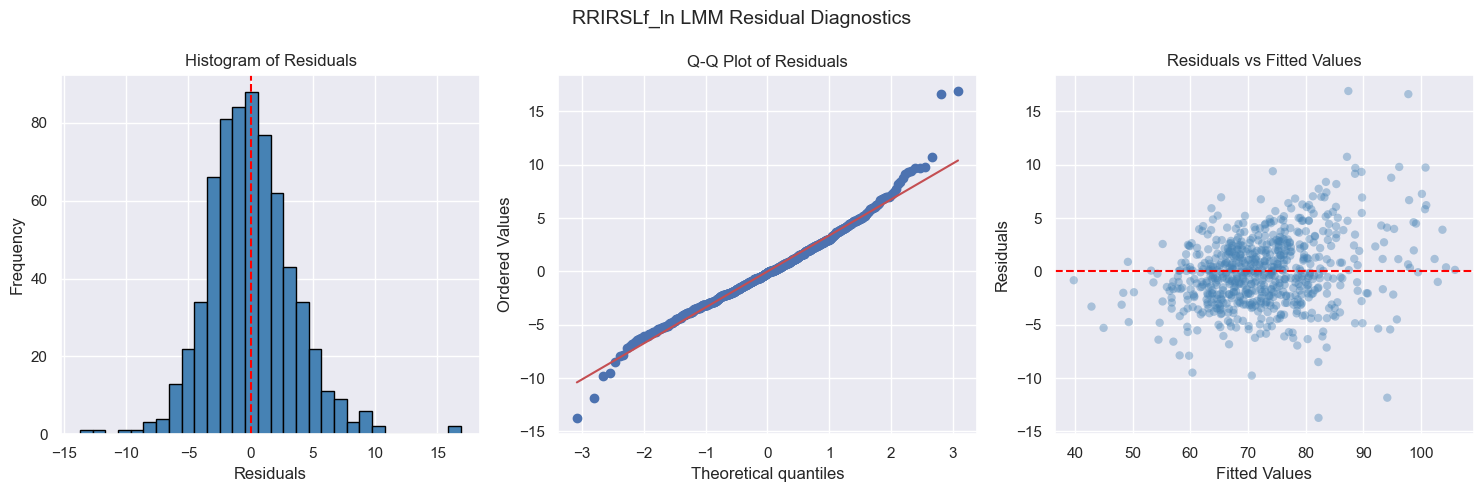

In [25]:
import matplotlib.pyplot as plt
import scipy.stats as stats
sns.set_theme(style='darkgrid')

## Extract residuals from the fitted model
residuals = model_RRIRSLf_ln.residuals

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('RRIRSLf_ln LMM Residual Diagnostics', fontsize=14)

## Plot 1: Histogram of residuals
axes[0].hist(residuals, bins=30, edgecolor='black', color='steelblue')
axes[0].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[0].set_title('Histogram of Residuals')
axes[0].set_xlabel('Residuals')
axes[0].set_ylabel('Frequency')

## Plot 2: Q-Q plot
stats.probplot(residuals, dist='norm', plot=axes[1])
axes[1].set_title('Q-Q Plot of Residuals')

## Plot 3: Residuals vs Fitted values
fitted = model_HRMean.fits
axes[2].scatter(fitted, residuals, alpha=0.4, color='steelblue', edgecolors='none')
axes[2].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[2].set_title('Residuals vs Fitted Values')
axes[2].set_xlabel('Fitted Values')
axes[2].set_ylabel('Residuals')

plt.tight_layout()
plt.show()

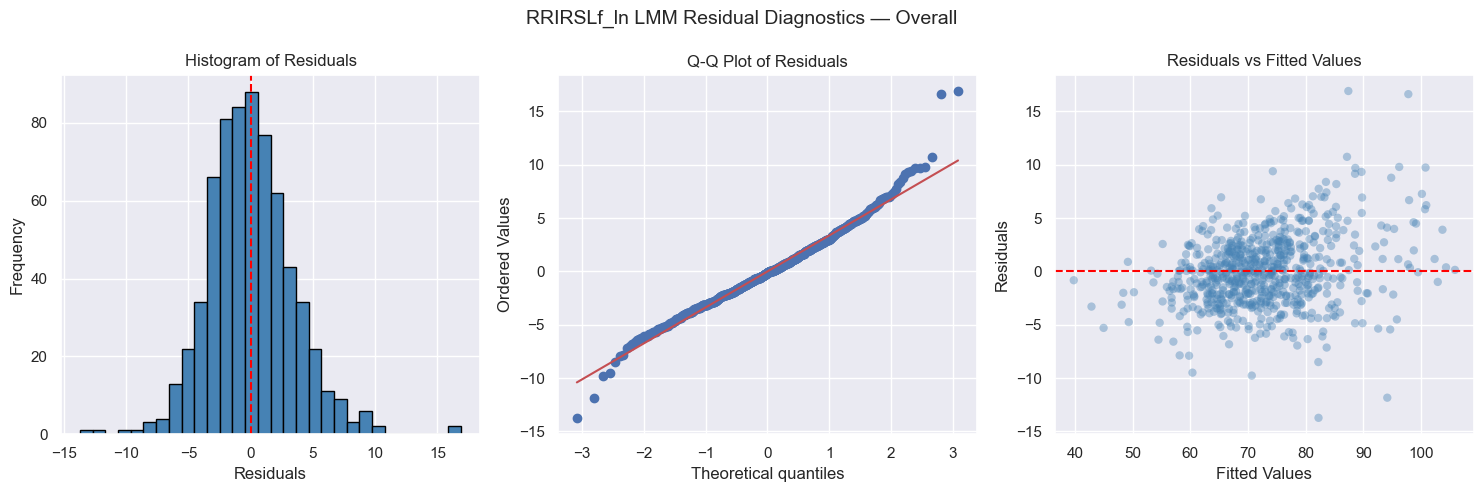

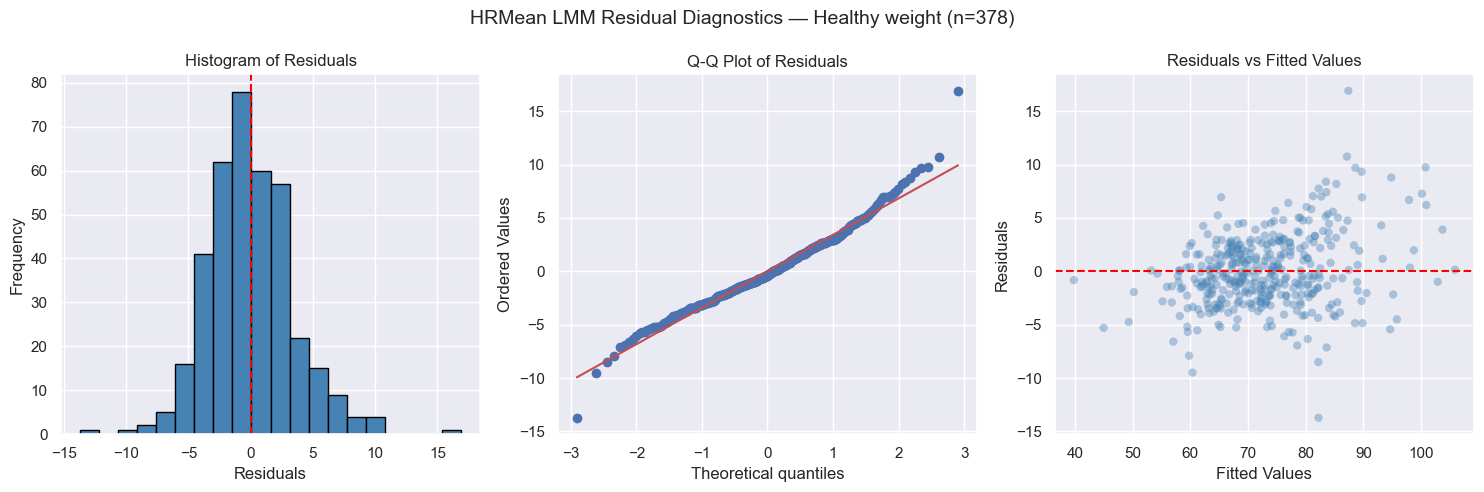

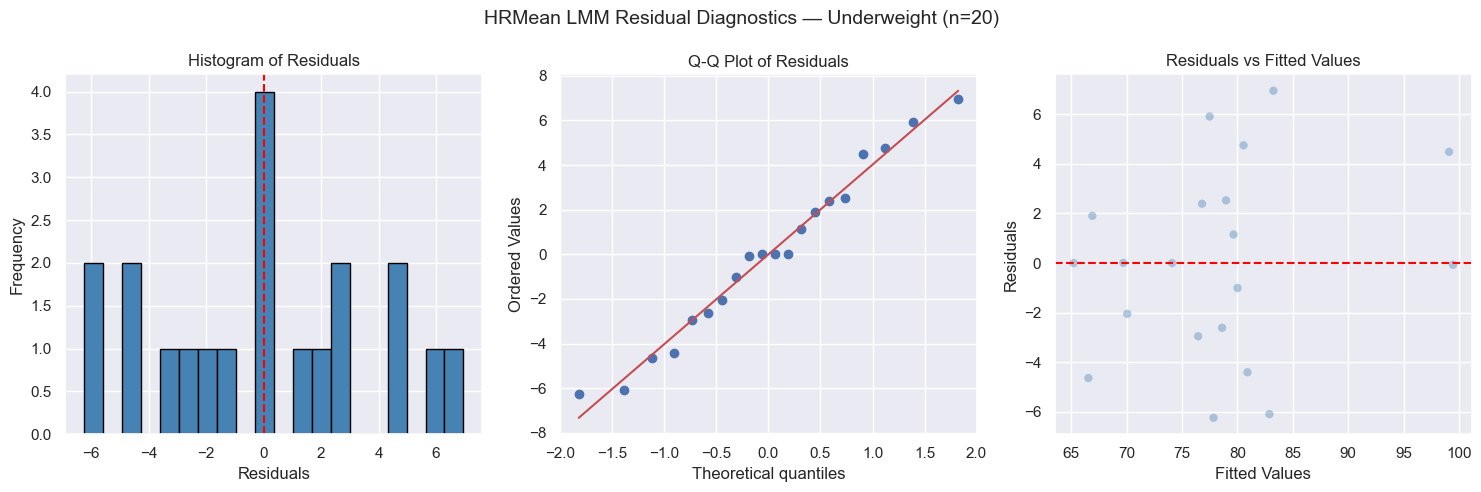

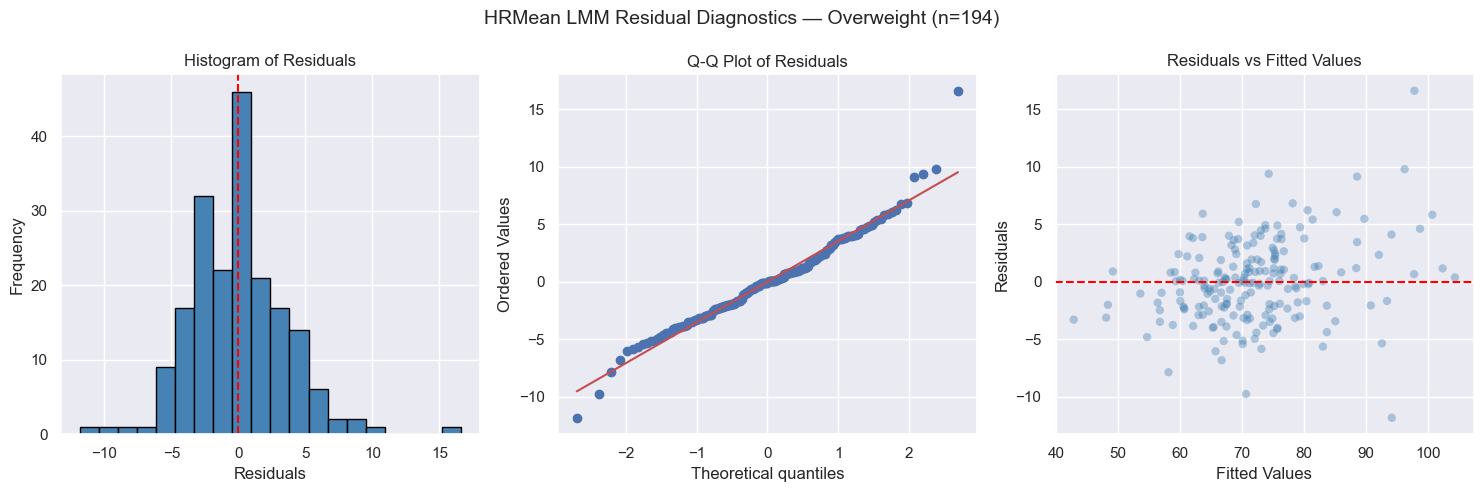

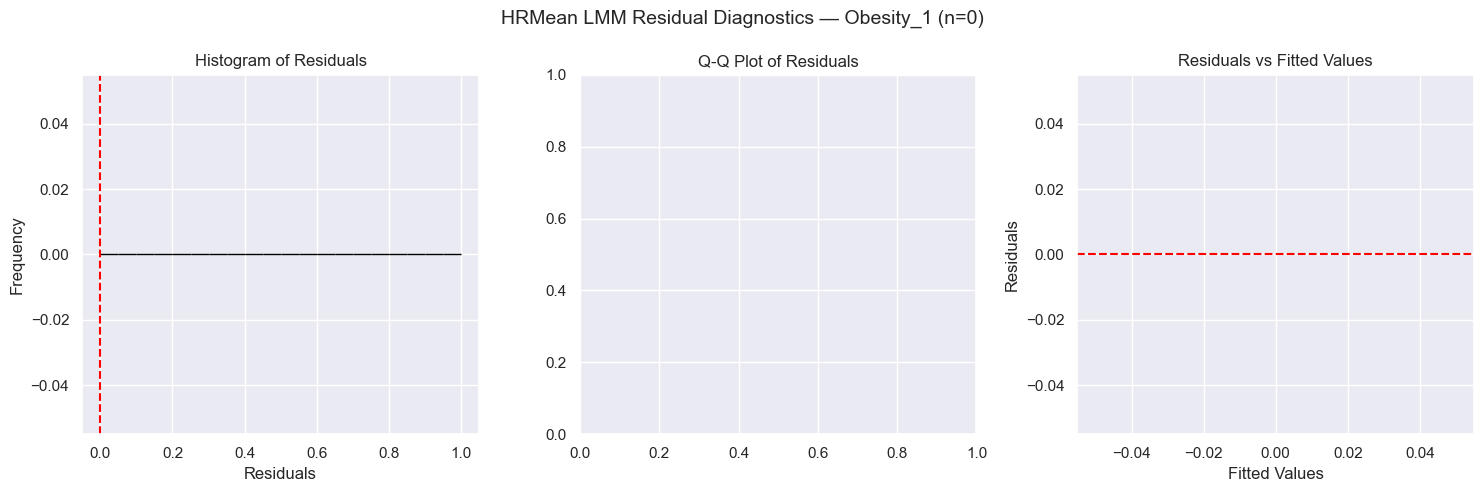

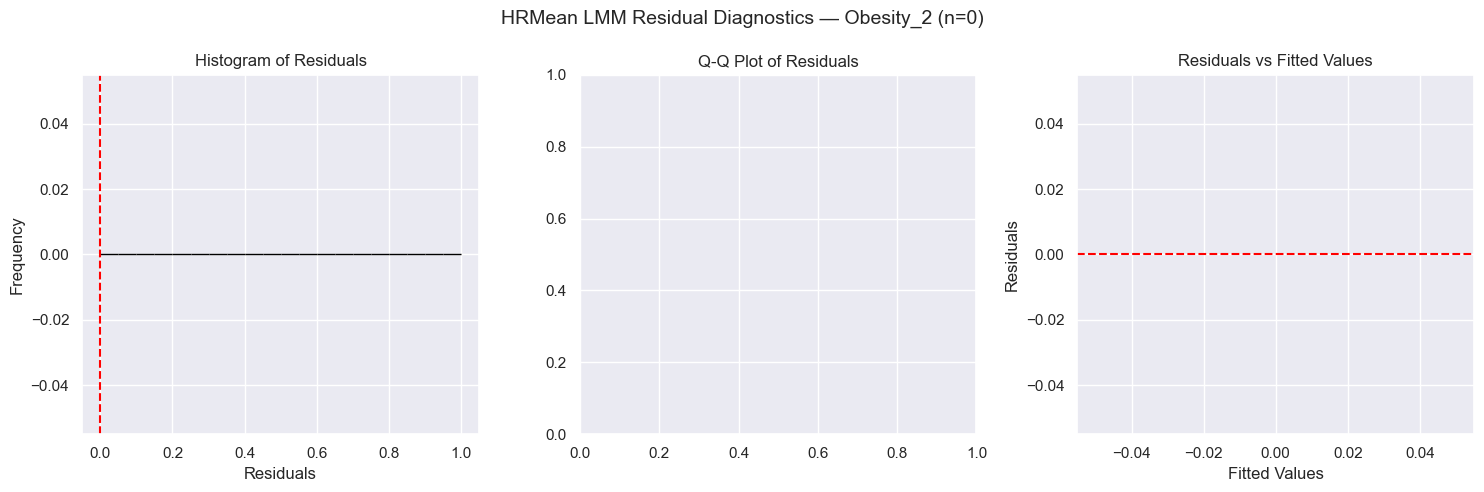

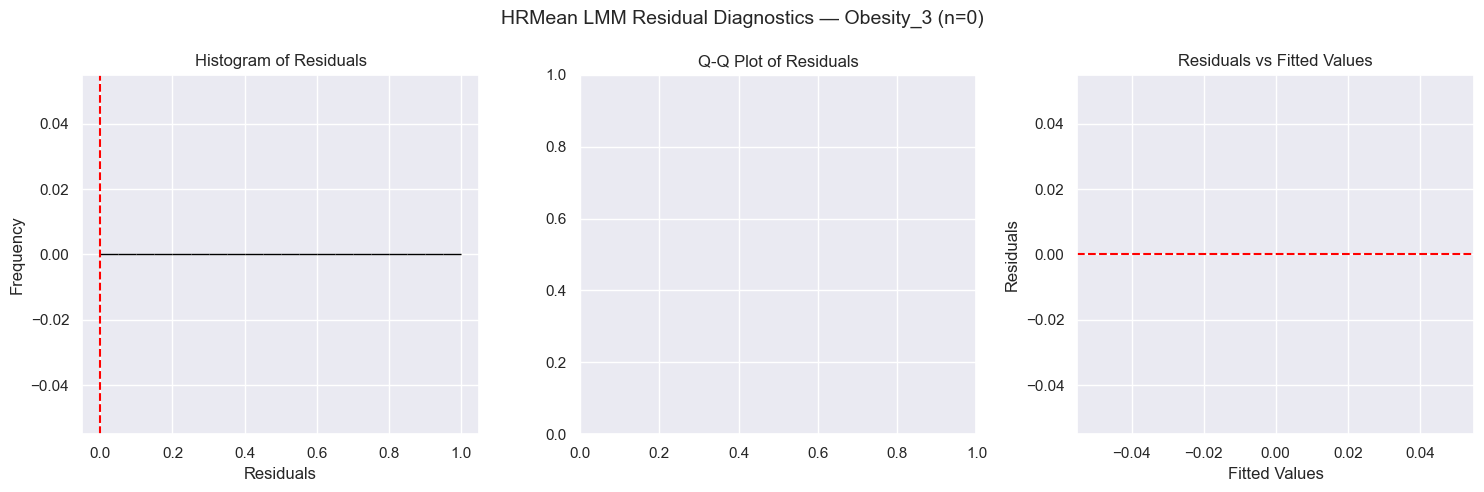

In [26]:
import matplotlib.pyplot as plt
import scipy.stats as stats
import seaborn as sns
sns.set_theme(style='darkgrid')

# Extract residuals and fitted values, attach bmi_cat from lmm_df
residuals = model_RRIRSLf_ln.residuals
fitted = model_RRIRSLf_ln.fits

resid_df = pd.DataFrame({
    'residuals': residuals,
    'fitted': fitted,
    'bmi_cat': lmm_df['bmi_cat'].values
})

# ── Overall Diagnostics ────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('RRIRSLf_ln LMM Residual Diagnostics — Overall', fontsize=14)

axes[0].hist(residuals, bins=30, edgecolor='black', color='steelblue')
axes[0].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[0].set_title('Histogram of Residuals')
axes[0].set_xlabel('Residuals')
axes[0].set_ylabel('Frequency')

stats.probplot(residuals, dist='norm', plot=axes[1])
axes[1].set_title('Q-Q Plot of Residuals')

axes[2].scatter(fitted, residuals, alpha=0.4, color='steelblue', edgecolors='none')
axes[2].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[2].set_title('Residuals vs Fitted Values')
axes[2].set_xlabel('Fitted Values')
axes[2].set_ylabel('Residuals')

plt.tight_layout()
plt.show()

# ── Per BMI Category Diagnostics ──────────────────────────────────
bmi_groups = ['Healthy weight', 'Underweight', 'Overweight',
              'Obesity_1', 'Obesity_2', 'Obesity_3']

for group in bmi_groups:
    group_data = resid_df[resid_df['bmi_cat'] == group]
    group_resid = group_data['residuals'].values
    group_fitted = group_data['fitted'].values
    n = len(group_resid)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(f'HRMean LMM Residual Diagnostics — {group} (n={n})', fontsize=14)

    # Histogram
    axes[0].hist(group_resid, bins=20, edgecolor='black', color='steelblue')
    axes[0].axvline(0, color='red', linestyle='--', linewidth=1.5)
    axes[0].set_title('Histogram of Residuals')
    axes[0].set_xlabel('Residuals')
    axes[0].set_ylabel('Frequency')

    # Q-Q plot
    stats.probplot(group_resid, dist='norm', plot=axes[1])
    axes[1].set_title('Q-Q Plot of Residuals')

    # Residuals vs Fitted
    axes[2].scatter(group_fitted, group_resid, alpha=0.4, 
                    color='steelblue', edgecolors='none')
    axes[2].axhline(0, color='red', linestyle='--', linewidth=1.5)
    axes[2].set_title('Residuals vs Fitted Values')
    axes[2].set_xlabel('Fitted Values')
    axes[2].set_ylabel('Residuals')

    plt.tight_layout()
    plt.show()